# Part 2: Classical Forecasting — Naive, Seasonal Naive, ETS
**⏱ This section takes approximately 30–40 minutes.**

---

## Scenario: Wednesday — Three Baselines That Should Be Tried First

Yesterday Sarah decomposed the series into trend + weekly seasonality + residual. Today she builds the simplest baseline forecasts and tries three classical methods to see if they do better on a holiday-period test window.

**The hierarchy of forecasting effort:**
1. **Naive** — predict the last observed value. The easiest possible baseline.
2. **Seasonal Naive** — predict the value from one season ago.
3. **ETS (Exponential Smoothing)** — adaptive level + trend + seasonality. The pragmatic baseline every forecaster should know.

If a fancier model can't beat these, ship one of them.

**By the end of this notebook you will be able to:**
- Build three baseline forecasts in a few lines each
- Fit an ETS model with `statsmodels`
- Compare all three on the same test window with MAE / RMSE / MAPE
- Understand when ETS helps — and when it doesn't

In [1]:
# Setup — load the tools we need
import numpy as np                 # numpy = maths on arrays of numbers
import pandas as pd                # pandas = tables of data
import matplotlib.pyplot as plt   # matplotlib = charts
import warnings

# ETS models: forecasting by smoothing recent history (heavier weight on recent days)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
# Standard error metrics to score every forecast the same way
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 4.5)

print("✅ Libraries loaded — statsmodels ExponentialSmoothing ready")

✅ Libraries loaded — statsmodels ExponentialSmoothing ready


## Step 1 — Setup + train/test split

We forecast the LAST 90 days (matching Sarah's 90-day deliverable horizon). Holding out the most recent 90 days mimics real deployment: train on the past, evaluate on the future.

In [2]:
# Load the data and pull out the revenue series
df = pd.read_csv("data/northstar_daily_revenue.csv", parse_dates=["date"])
df = df.set_index("date")
y = df["revenue_gbp"]

# Hold out the LAST 90 days as the "future" we pretend not to know —
# train on the past, then check how well we would have predicted it
TEST_SIZE = 90
y_train = y.iloc[:-TEST_SIZE]   # everything except the last 90 days
y_test  = y.iloc[-TEST_SIZE:]   # the last 90 days — never shown to the models

print(f"Train: {len(y_train)} days ({y_train.index[0].date()} to {y_train.index[-1].date()})")
print(f"Test:  {len(y_test)} days ({y_test.index[0].date()} to {y_test.index[-1].date()})")
print(f"Test period covers the October-December run-up → holiday-shopping season.")

Train: 641 days (2024-01-01 to 2025-10-02)
Test:  90 days (2025-10-03 to 2025-12-31)
Test period covers the October-December run-up → holiday-shopping season.


## Step 2 — Method 1: Naive (predict the last value)

The trivial baseline: every forecast equals the last observed value.

We score every method with three standard error metrics (defined once in the `evaluate` helper below):

- **MAE (Mean Absolute Error)** — the average forecast error in the original units (£), showing how far predictions are from actual values on a typical day.
- **MAPE (Mean Absolute Percentage Error)** — the average error expressed as a percentage of the actual value, making it easier to judge accuracy relative to the size of the business.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalises large mistakes more heavily, making it sensitive to occasional bad forecasts.

In [3]:
# Naive method: predict the same value (the last training day) for ALL 90 test days
naive_forecast = pd.Series(
    [y_train.iloc[-1]] * len(y_test),   # repeat the last known value 90 times
    index=y_test.index,                 # line it up with the test dates
    name="naive"
)

# Helper: score any forecast with the three standard metrics
def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)            # average £ error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))    # like MAE but punishes big misses more
    mape = (np.abs(y_true - y_pred) / y_true).mean() * 100  # average % error — easy for Marcus to read
    return {"method": name, "MAE": mae, "RMSE": rmse, "MAPE_pct": mape}

results = []                                               # we'll collect every method's scores here
results.append(evaluate(y_test, naive_forecast, "Naive"))
print(f"Naive — predict {y_train.iloc[-1]:.0f} for all {len(y_test)} test days:")
for k, v in results[-1].items():
    if k != "method": print(f"  {k}: {v:.2f}" if k == "MAPE_pct" else f"  {k}: £{v:,.0f}")

Naive — predict 7380 for all 90 test days:
  MAE: £3,346
  RMSE: £3,758
  MAPE_pct: 29.33


## Step 3 — Method 2: Seasonal Naive (predict value from one season ago)

Seasonal Naive repeats the last full season. With weekly seasonality (period=7), the forecast for each future day is the value from the **same weekday in the last observed week**, tiled forward across the whole horizon. So the forecast keeps the weekly up-and-down shape (weekend lift, weekday dip) for all 90 days — it does NOT flatten out.

What it cannot do is follow a rising trend: every week of the forecast is a copy of that one last training week.

In [4]:
# Seasonal Naive: tile the last 7 observed (training) days across the whole horizon.
# The last 7 training days end the day before the test window, so day-of-week stays aligned:
# test day 0 = value 7 days earlier, test day 7 = same as test day 0, and so on.
last_season = y_train.iloc[-7:].values          # Mon..Sun pattern of the final training week
snaive_values = [last_season[i % 7] for i in range(len(y_test))]
snaive_forecast = pd.Series(snaive_values, index=y_test.index, name="snaive")

results.append(evaluate(y_test, snaive_forecast, "Seasonal Naive (lag-7)"))
for k, v in results[-1].items():
    if k != "method": print(f"  {k}: {v:.2f}" if k == "MAPE_pct" else f"  {k}: £{v:,.0f}")

  MAE: £2,400
  RMSE: £2,873
  MAPE_pct: 20.74


## ⏸️ Pause and Predict

### ETS (Error, Trend, Seasonal)

ETS is an exponential smoothing model that forecasts by tracking patterns in a time series and updating them as new data arrives. It places greater weight on recent observations while still retaining information from the past — so recent behaviour influences predictions more than older behaviour.

At each step, the model compares its forecast to the actual value. The difference between the two — the **Error** component — is used as feedback to adjust the model's understanding of the pattern going forward. So "Error" here does not mean the model is predicting future mistakes; it means the model is continuously self-correcting based on how wrong it just was.

This is what separates ETS from simpler approaches like Naive and Seasonal Naive, which just repeat past observations without any adjustment. ETS can adapt when patterns shift — making it more accurate in situations where trends or seasonality are present and evolving.

Before running ETS, predict:

- Will ETS beat Seasonal Naive on this test window? By how much?
- Two reasonable hyperparameter choices: `seasonal_periods=7` (weekly) or `seasonal_periods=365` (annual). Which would be better for capturing the November-December holiday spike?

> *Sample answers:*
> - ETS with weekly seasonality will probably beat Seasonal Naive modestly — it ALSO models the upward trend, which Seasonal Naive doesn't.
> - ETS with annual seasonality (period=365) SHOULD be much better for the holiday-window test — it would know "Nov-Dec is high every year." But we only have 2 years of training data, which is too little to reliably fit an annual seasonality. The model may not converge well.

## Step 4 — Method 3: ETS / Exponential Smoothing

We try TWO ETS variants:
- **Weekly seasonality** (period=7) — captures weekend lift + trend
- **Annual seasonality** (period=365) — captures the November-December holiday spike, but needs enough years of data to fit

Then we pick the best.

In [5]:
# ETS with weekly seasonality (period=7)
ets_weekly = ExponentialSmoothing(
    y_train,
    trend="add",            # model a trend that ADDS a fixed amount per period
    seasonal="add",         # seasonal effect also added (e.g. "+£900 on Saturdays")
    seasonal_periods=7,     # the pattern repeats every 7 days (weekly)
).fit()                     # learn the smoothing weights from the training data

ets_weekly_forecast = ets_weekly.forecast(steps=len(y_test))   # project 90 days ahead
ets_weekly_forecast.index = y_test.index                       # align to the test dates

results.append(evaluate(y_test, ets_weekly_forecast, "ETS (weekly, trend+seasonal)"))
print(f"ETS (weekly seasonality):")
for k, v in results[-1].items():
    if k != "method": print(f"  {k}: {v:.2f}" if k == "MAPE_pct" else f"  {k}: £{v:,.0f}")

ETS (weekly seasonality):
  MAE: £2,246
  RMSE: £2,692
  MAPE_pct: 19.32


In [6]:
# ETS with annual seasonality (period=365) — note: training has ~1.8 cycles only
# try/except because statsmodels refuses to fit if there are fewer than 2 full cycles
try:
    ets_annual = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=365,    # "the pattern repeats every 365 days" — the holiday cycle
    ).fit()
    ets_annual_forecast = ets_annual.forecast(steps=len(y_test))   # 90 days ahead
    ets_annual_forecast.index = y_test.index

    results.append(evaluate(y_test, ets_annual_forecast, "ETS (annual, trend+seasonal)"))
    print(f"ETS (annual seasonality):")
    for k, v in results[-1].items():
        if k != "method": print(f"  {k}: {v:.2f}" if k == "MAPE_pct" else f"  {k}: £{v:,.0f}")
except Exception as e:
    ets_annual_forecast = None     # remember it failed so later cells can skip it
    print(f"ETS-annual failed to fit: {e}")

print("The model needs at least two full cycles because it uses the first year to establish the baseline seasonal patterns and the second year to verify how those patterns repeat over time.")

ETS-annual failed to fit: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
The model needs at least two full cycles because it uses the first year to establish the baseline seasonal patterns and the second year to verify how those patterns repeat over time.


## Step 5 — Comparison table

In [7]:
# Turn the list of score-dictionaries into a tidy comparison table
results_df = pd.DataFrame(results).set_index("method")
print(results_df.round(2).to_string())
print()

# Pick the best method = the one with the smallest average £ error (MAE)
best_method = results_df["MAE"].idxmin()
print(f"Best on MAE: {best_method}  (MAE = £{results_df.loc[best_method, 'MAE']:,.0f})")

                                  MAE     RMSE  MAPE_pct
method                                                  
Naive                         3345.53  3758.12     29.33
Seasonal Naive (lag-7)        2400.13  2873.35     20.74
ETS (weekly, trend+seasonal)  2246.23  2692.23     19.32

Best on MAE: ETS (weekly, trend+seasonal)  (MAE = £2,246)


### 💡 What you should notice

- **Naive is terrible** (MAE ≈ £3,300, MAPE ≈ 29%) — it ignores both trend AND seasonality, and predicting a single early-October day for all 90 days badly undershoots the holiday run-up. It's the floor.
- **Seasonal Naive captures weekly seasonality** (MAPE ≈ 21%) but misses the rising holiday trend — every forecast week is a copy of the last training week.
- **ETS-weekly wins among the classical methods** (MAE ≈ £2,250, MAPE ≈ 19%) — ETS-weekly only improves slightly over Seasonal Naive because it captures a smooth additive trend, but it still cannot represent multiple seasonal patterns or holiday-driven shifts.
- **ETS-annual** would be the natural fit for an annual holiday spike, but it **fails to fit**: with under two full annual cycles in the training data, statsmodels can't initialise a 365-day seasonal component.

The **key insight**: classical models handle ONE seasonality. Our data has TWO (weekly + annual). That's why tomorrow's ML method with lag features at multiple horizons is the right tool.

Because ML uses lag features directly, it can learn multiple seasonal and holiday effects at once without needing predefined decomposition or fixed seasonal assumptions. Because of this flexibility, it adapts better to changing trends and interacting time patterns than classical models that separate trend and seasonality in advance.

## Step 6 — Visualise all forecasts together

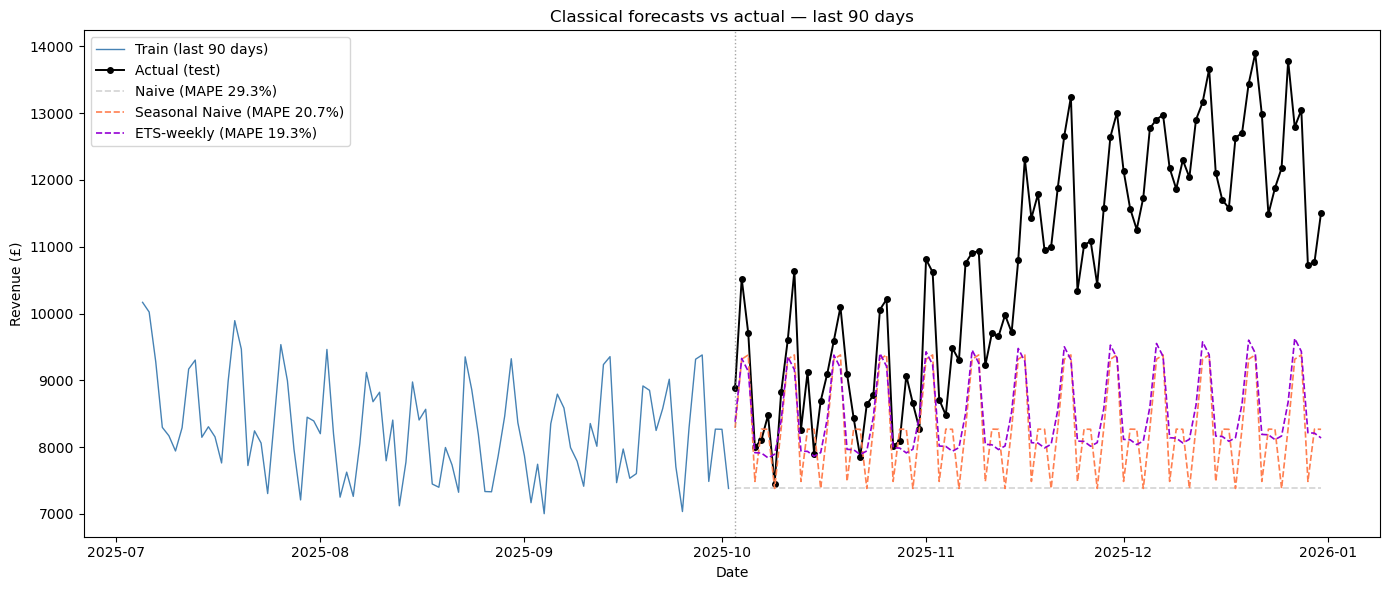

In [8]:
# One chart with everything: recent history, the true test values, and every forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Last 90 days of train for context (so the eye can follow history into the forecast)
ax.plot(y_train.iloc[-90:].index, y_train.iloc[-90:].values,
        color="steelblue", linewidth=1.0, label="Train (last 90 days)")
# The truth we held back — black dots
ax.plot(y_test.index, y_test.values, "o-", color="black",
        markersize=4, linewidth=1.4, label="Actual (test)")

# Each method's forecast as a dashed line, with its MAPE in the legend
ax.plot(naive_forecast.index, naive_forecast.values, "--",
        color="lightgray", linewidth=1.2, label=f"Naive (MAPE {results_df.loc['Naive','MAPE_pct']:.1f}%)")
ax.plot(snaive_forecast.index, snaive_forecast.values, "--",
        color="coral", linewidth=1.2, label=f"Seasonal Naive (MAPE {results_df.loc['Seasonal Naive (lag-7)','MAPE_pct']:.1f}%)")
ax.plot(ets_weekly_forecast.index, ets_weekly_forecast.values, "--",
        color="darkviolet", linewidth=1.2,
        label=f"ETS-weekly (MAPE {results_df.loc['ETS (weekly, trend+seasonal)','MAPE_pct']:.1f}%)")

# Only plot ETS-annual if it actually fitted
if ets_annual_forecast is not None:
    ax.plot(ets_annual_forecast.index, ets_annual_forecast.values, "--",
            color="seagreen", linewidth=1.2,
            label=f"ETS-annual (MAPE {results_df.loc['ETS (annual, trend+seasonal)','MAPE_pct']:.1f}%)")

ax.axvline(y_test.index[0], color="gray", linestyle=":", linewidth=1, alpha=0.7)   # mark where the test starts
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("Classical forecasts vs actual — last 90 days")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

## Step 7 — Inspect the residual structure of the best classical model

If a forecast has SYSTEMATIC errors (consistently over or under), that's a structural problem the model didn't capture. Plot the residuals.

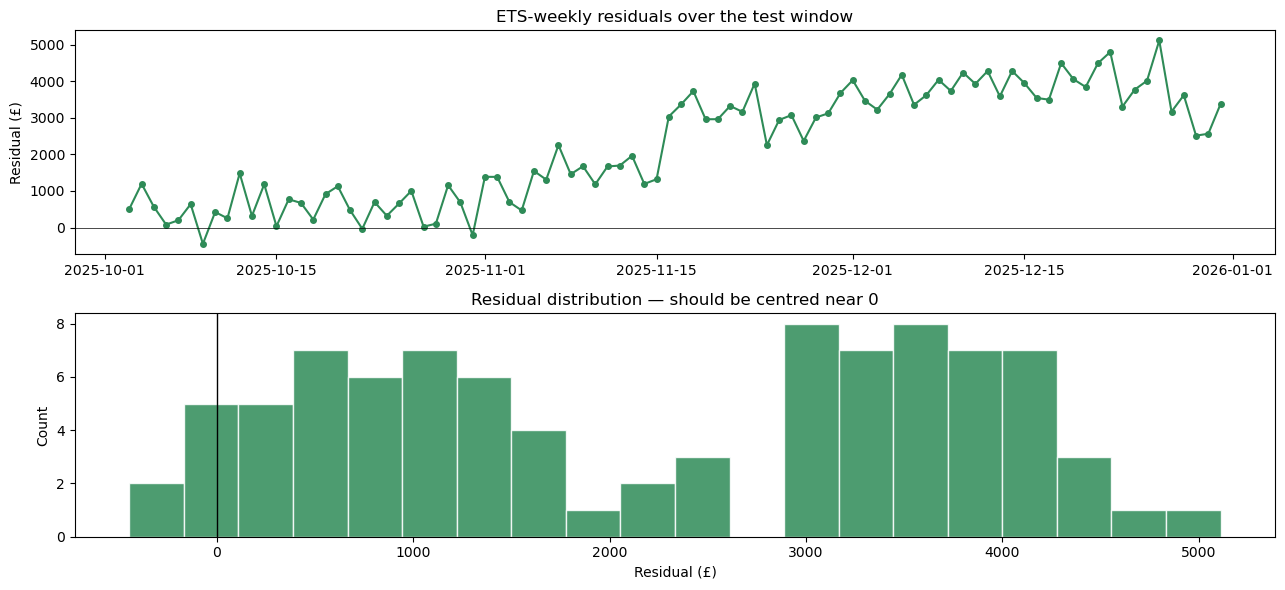

Mean residual:   £+2231  (positive = model underforecasts)
Median residual: £+2310


In [9]:
# Use the best ETS variant (probably weekly)
best_classical = ets_weekly_forecast
residuals = y_test - best_classical    # residual = actual minus forecast, day by day

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

# Chart 1: residual over time — are the errors random, or consistently on one side of zero?
axes[0].plot(residuals.index, residuals.values, "o-", color="seagreen", markersize=4)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Residual (£)")
axes[0].set_title(f"ETS-weekly residuals over the test window")

# Chart 2: histogram of the errors — a healthy model is centred near zero
axes[1].hist(residuals, bins=20, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual (£)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution — should be centred near 0")

plt.tight_layout()
plt.show()

print(f"Mean residual:   £{residuals.mean():+.0f}  (positive = model underforecasts)")
print(f"Median residual: £{residuals.median():+.0f}")

### 💡 What this tells us

- **Positive mean residual** = the model **under-forecasts**. That's typical when forecasting through a rising holiday season with a model that only knows weekly seasonality.
- **The residual chart** shows whether the under-forecast is consistent (every day a bit low) or spiky (just a few days).

This is exactly why we need Thursday's ML approach — it can capture annual seasonality through lag-365 features.

## ✅ Section Summary

| Method | When it works | When it fails |
|---|---|---|
| **Naive** | Series with no trend, no seasonality | Always — but it's the bar floor |
| **Seasonal Naive** | Stable seasonal pattern, no trend | Strong trend or rising seasons |
| **ETS-weekly** | Series with one seasonal cycle | Multi-seasonal data |
| **ETS-annual** | Long enough training data (3+ years) | Limited annual data, convergence issues |

**Result on THIS test window (last 90 days, the holiday run-up):**
> ETS-weekly is the best classical method (MAE ≈ £2,250, MAPE ≈ 19%), edging out Seasonal Naive (≈ 21%); Naive is the floor (≈ 29%). But these are scores on ONE window — never trust a single split. Tomorrow's notebook cross-validates with `TimeSeriesSplit` over several rolling windows, so you don't reward a method that simply got lucky on one stretch of dates.

**Friday recommendation so far:**
> Classical methods (especially ETS-weekly) capture trend + weekly seasonality. They miss the annual holiday spike — ETS-annual can't even fit with only ~2 years of data. Tomorrow's ML method with lag features at multiple horizons (lag-1, lag-7, lag-365) handles BOTH seasonalities at once. That's likely the winner.

**Key insights:**
- **ALWAYS start with a baseline.** Naive + Seasonal Naive define the floor.
- **ETS captures level + trend + ONE seasonality** — pragmatic baseline that's been used for decades.
- **For multi-seasonal data**, classical methods leave room on the table. ML approaches with multi-lag features fill that gap.

---
**Up next → Part 3:** Thursday — ML-based forecasting with lag features + HistGradientBoostingRegressor. The method that should finally beat all the classical baselines.
Open `04_ml_forecasting.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — SimpleExpSmoothing (level only, no trend, no seasonality)

The simplest form of exponential smoothing — just adaptive weighted average. Useful when there's no clear trend OR seasonality.

In [10]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit the simplest smoother: no trend, no seasonality — just a moving weighted average
ses = SimpleExpSmoothing(y_train).fit()
ses_forecast = ses.forecast(steps=len(y_test))   # projects an (almost) flat line 90 days ahead
ses_forecast.index = y_test.index

ses_result = evaluate(y_test, ses_forecast, "SimpleExpSmoothing")   # score it like the others
print(f"SimpleExpSmoothing: MAE £{ses_result['MAE']:,.0f}, MAPE {ses_result['MAPE_pct']:.1f}%")
print(f"  → essentially predicts a flat line — no trend, no seasonality.")
print(f"  → useful as a sanity-check baseline; almost always beaten by ETS-weekly.")

SimpleExpSmoothing: MAE £2,601, MAPE 22.3%
  → essentially predicts a flat line — no trend, no seasonality.
  → useful as a sanity-check baseline; almost always beaten by ETS-weekly.


## Extension 2 — ETS with multiplicative seasonality

The default `seasonal="add"` assumes the weekly amplitude is the same regardless of overall level. `seasonal="mul"` assumes the amplitude SCALES with the level (10% weekend lift, whether revenue is £8k or £12k).

In [11]:
# Same ETS as before, but seasonal="mul": the weekly swing GROWS as revenue grows
try:
    ets_mul = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="mul",         # multiplicative: "+10% on weekends" instead of "+£900 on weekends"
        seasonal_periods=7,
    ).fit()
    ets_mul_forecast = ets_mul.forecast(steps=len(y_test))
    ets_mul_forecast.index = y_test.index
    mul_result = evaluate(y_test, ets_mul_forecast, "ETS-weekly (mul)")
    # Compare head-to-head with the additive version from the core section
    print(f"ETS-weekly with multiplicative seasonality: MAE £{mul_result['MAE']:,.0f}, MAPE {mul_result['MAPE_pct']:.1f}%")
    print(f"vs additive: MAE £{results_df.loc['ETS (weekly, trend+seasonal)','MAE']:,.0f}, MAPE {results_df.loc['ETS (weekly, trend+seasonal)','MAPE_pct']:.1f}%")
except Exception as e:
    print(f"Multiplicative ETS failed: {e}")

ETS-weekly with multiplicative seasonality: MAE £2,254, MAPE 19.4%
vs additive: MAE £2,246, MAPE 19.3%


## Extension 3 — Forecast 90 days into the FUTURE (no actual to compare)

So far we've been forecasting where we have ground truth. The real deployment task: forecast Jan-Mar 2026 (no data yet). Sarah's Friday deliverable.

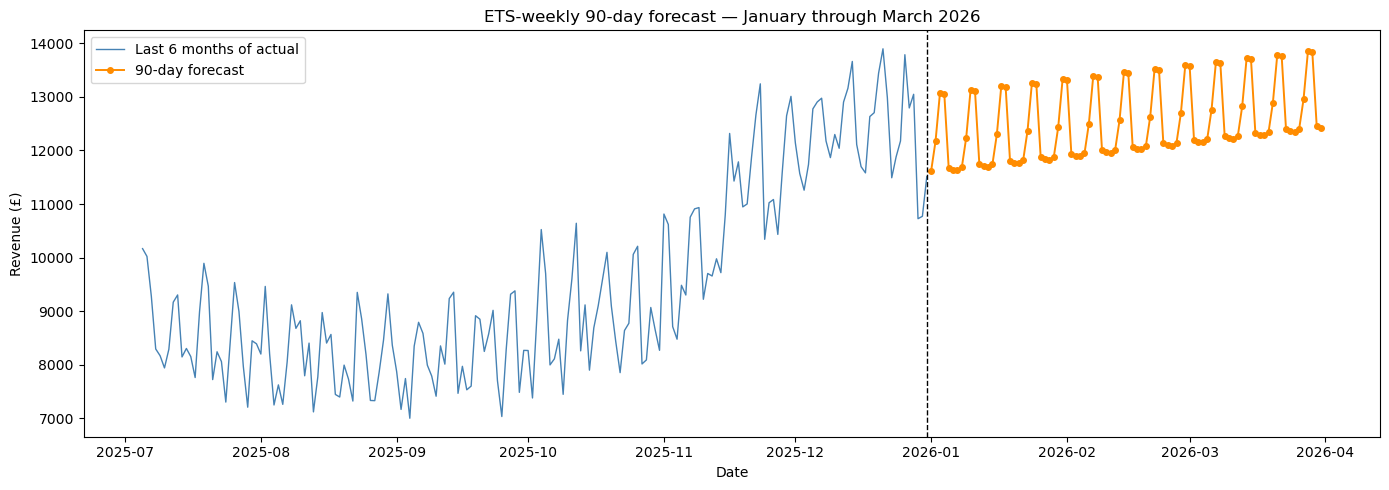

Forecasted total revenue Jan-Mar 2026: £1,126,409
Average daily forecast: £12,516

Sarah's Friday number for Marcus.


In [12]:
# Real deployment: re-fit on ALL data (no hold-out) and forecast 90 days we have NO answers for
ets_final = ExponentialSmoothing(
    y, trend="add", seasonal="add", seasonal_periods=7,
).fit()
forecast_90 = ets_final.forecast(steps=90)   # Jan-Mar 2026

fig, ax = plt.subplots(figsize=(14, 5))
# Last 6 months of history for context
ax.plot(y.iloc[-180:].index, y.iloc[-180:].values, color="steelblue",
        linewidth=1.0, label="Last 6 months of actual")
# The forecast, in orange, continuing where history ends
ax.plot(forecast_90.index, forecast_90.values, "o-", color="darkorange",
        markersize=4, linewidth=1.4, label="90-day forecast")
ax.axvline(y.index[-1], color="black", linestyle="--", linewidth=1)   # "today" line
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("ETS-weekly 90-day forecast — January through March 2026")
ax.legend()
plt.tight_layout()
plt.show()

# Headline numbers for the business
print(f"Forecasted total revenue Jan-Mar 2026: £{forecast_90.sum():,.0f}")
print(f"Average daily forecast: £{forecast_90.mean():,.0f}")
print()
print("Sarah's Friday number for Marcus.")